# Regularization: L1 vs L2
### Preventing Overfitting with Penalties

**Regularization = Adding penalty to loss function**
- L1 (Lasso): Sparse solutions, feature selection
- L2 (Ridge): Weight shrinkage, smooth solutions
- Goal: Simpler models that generalize better

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("bright")
np.random.seed(42)

## 1. The Penalty Functions
**Visual comparison of L1 and L2**

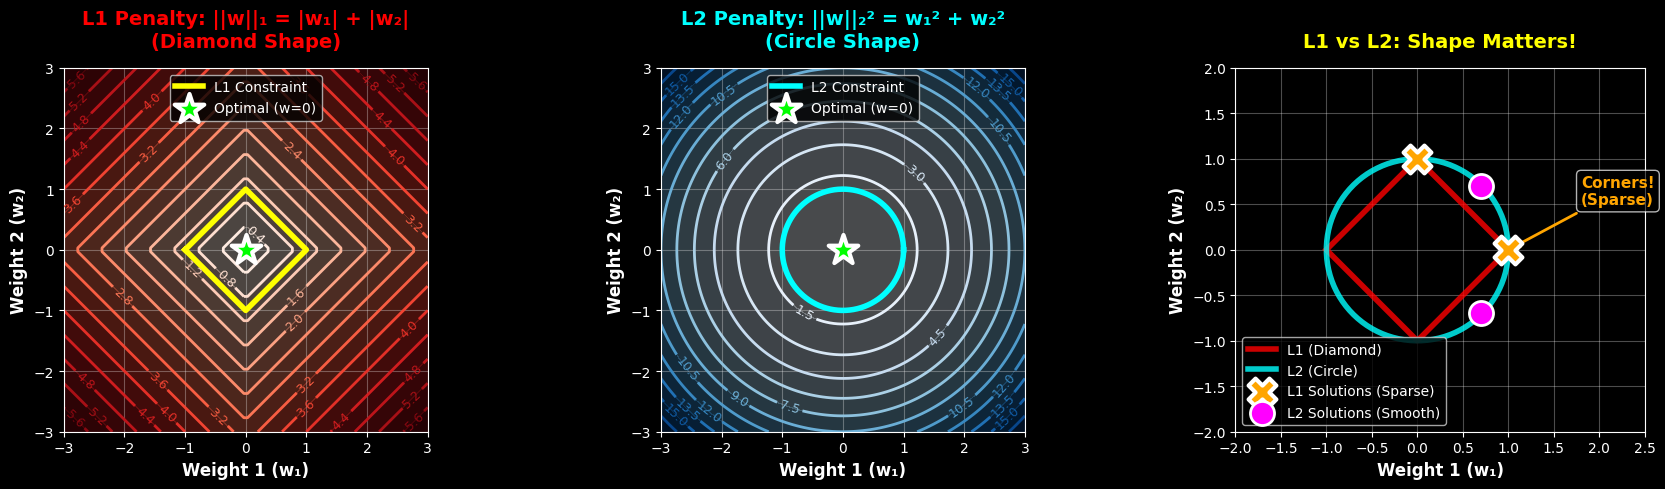

Key Difference:
L1 (Diamond): Corners hit axes → SPARSE solutions (some w=0)
L2 (Circle): Smooth → All weights shrunk but non-zero


In [2]:
# Create weight space
w1 = np.linspace(-3, 3, 100)
w2 = np.linspace(-3, 3, 100)
W1, W2 = np.meshgrid(w1, w2)

# L1 penalty: |w1| + |w2|
L1_penalty = np.abs(W1) + np.abs(W2)

# L2 penalty: w1² + w2²
L2_penalty = W1**2 + W2**2

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: L1 Penalty
ax1 = axes[0]
contour1 = ax1.contour(W1, W2, L1_penalty, levels=15, cmap='Reds', linewidths=2)
ax1.contourf(W1, W2, L1_penalty, levels=15, cmap='Reds', alpha=0.3)
ax1.clabel(contour1, inline=True, fontsize=9)

# Draw diamond shape
diamond = np.array([[-1, 0], [0, 1], [1, 0], [0, -1], [-1, 0]])
ax1.plot(diamond[:, 0], diamond[:, 1], 'yellow', linewidth=4, label='L1 Constraint')

ax1.scatter(0, 0, s=500, c='lime', marker='*', edgecolors='white', 
           linewidth=3, zorder=5, label='Optimal (w=0)')
ax1.set_xlabel('Weight 1 (w₁)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Weight 2 (w₂)', fontsize=12, fontweight='bold')
ax1.set_title('L1 Penalty: ||w||₁ = |w₁| + |w₂|\n(Diamond Shape)', 
             fontsize=14, fontweight='bold', color='red', pad=15)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_aspect('equal')

# Plot 2: L2 Penalty
ax2 = axes[1]
contour2 = ax2.contour(W1, W2, L2_penalty, levels=15, cmap='Blues', linewidths=2)
ax2.contourf(W1, W2, L2_penalty, levels=15, cmap='Blues', alpha=0.3)
ax2.clabel(contour2, inline=True, fontsize=9)

# Draw circle
theta = np.linspace(0, 2*np.pi, 100)
circle_x = np.cos(theta)
circle_y = np.sin(theta)
ax2.plot(circle_x, circle_y, 'cyan', linewidth=4, label='L2 Constraint')

ax2.scatter(0, 0, s=500, c='lime', marker='*', edgecolors='white', 
           linewidth=3, zorder=5, label='Optimal (w=0)')
ax2.set_xlabel('Weight 1 (w₁)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Weight 2 (w₂)', fontsize=12, fontweight='bold')
ax2.set_title('L2 Penalty: ||w||₂² = w₁² + w₂²\n(Circle Shape)', 
             fontsize=14, fontweight='bold', color='cyan', pad=15)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)
ax2.set_aspect('equal')

# Plot 3: Comparison
ax3 = axes[2]
ax3.plot(diamond[:, 0], diamond[:, 1], 'red', linewidth=4, 
        label='L1 (Diamond)', alpha=0.8)
ax3.plot(circle_x, circle_y, 'cyan', linewidth=4, 
        label='L2 (Circle)', alpha=0.8)

# Show sparsity effect
ax3.scatter([1, 0], [0, 1], s=400, c='orange', marker='X', 
           edgecolors='white', linewidth=3, zorder=5, 
           label='L1 Solutions (Sparse)')
ax3.scatter([0.7, 0.7], [0.7, -0.7], s=300, c='magenta', 
           edgecolors='white', linewidth=2, zorder=5, 
           label='L2 Solutions (Smooth)')

# Annotations
ax3.annotate('Corners!\n(Sparse)', xy=(1, 0), xytext=(1.8, 0.5),
            fontsize=11, fontweight='bold', color='orange',
            arrowprops=dict(arrowstyle='->', color='orange', lw=2),
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

ax3.set_xlabel('Weight 1 (w₁)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Weight 2 (w₂)', fontsize=12, fontweight='bold')
ax3.set_title('L1 vs L2: Shape Matters!', 
             fontsize=14, fontweight='bold', color='yellow', pad=15)
ax3.legend(fontsize=10, loc='lower left')
ax3.grid(alpha=0.3)
ax3.set_aspect('equal')
ax3.set_xlim([-2, 2.5])
ax3.set_ylim([-2, 2])

plt.tight_layout()
plt.show()

print("Key Difference:")
print("="*60)
print("L1 (Diamond): Corners hit axes → SPARSE solutions (some w=0)")
print("L2 (Circle): Smooth → All weights shrunk but non-zero")
print("="*60)

## 2. Generate Data with Many Features
**Some relevant, some irrelevant**

In [3]:
# Generate data with 20 features, only 5 are relevant
n_samples = 100
n_features = 20
n_relevant = 5

# Create features
X = np.random.randn(n_samples, n_features)

# True weights: only first 5 features matter
true_weights = np.zeros(n_features)
true_weights[:n_relevant] = [3, -2, 1.5, 2.5, -1.8]

# Generate target
y = X @ true_weights + np.random.randn(n_samples) * 0.5

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset: {n_samples} samples, {n_features} features")
print(f"Only {n_relevant} features are actually relevant!")
print(f"\nTrue weights (first 10): {true_weights[:10]}")

Dataset: 100 samples, 20 features
Only 5 features are actually relevant!

True weights (first 10): [ 3.  -2.   1.5  2.5 -1.8  0.   0.   0.   0.   0. ]


## 3. Compare Models
**No Regularization vs L1 vs L2**

In [4]:
# Train three models
models = {
    'No Regularization': LinearRegression(),
    'L1 (Lasso)': Lasso(alpha=0.1),
    'L2 (Ridge)': Ridge(alpha=1.0)
}

weights = {}

for name, model in models.items():
    model.fit(X_scaled, y)
    weights[name] = model.coef_
    
    # Count non-zero weights
    non_zero = np.sum(np.abs(model.coef_) > 0.01)
    print(f"{name:20s}: Non-zero weights = {non_zero:2d} / {n_features}")
    print(f"  Weights: {model.coef_[:10]}")

No Regularization   : Non-zero weights = 17 / 20
  Weights: [ 2.72164623 -1.99626082  1.60573071  2.37749403 -1.66201221  0.02245294
 -0.04973436  0.03967123 -0.09362991 -0.03418786]
L1 (Lasso)          : Non-zero weights =  5 / 20
  Weights: [ 2.65454226 -1.94371604  1.51627984  2.2917555  -1.55592547  0.
 -0.          0.         -0.         -0.        ]
L2 (Ridge)          : Non-zero weights = 17 / 20
  Weights: [ 2.69624905 -1.98222924  1.58749656  2.35330448 -1.64353812  0.02654463
 -0.04426528  0.03641025 -0.09552826 -0.02813568]


## 4. Weight Comparison Visualization

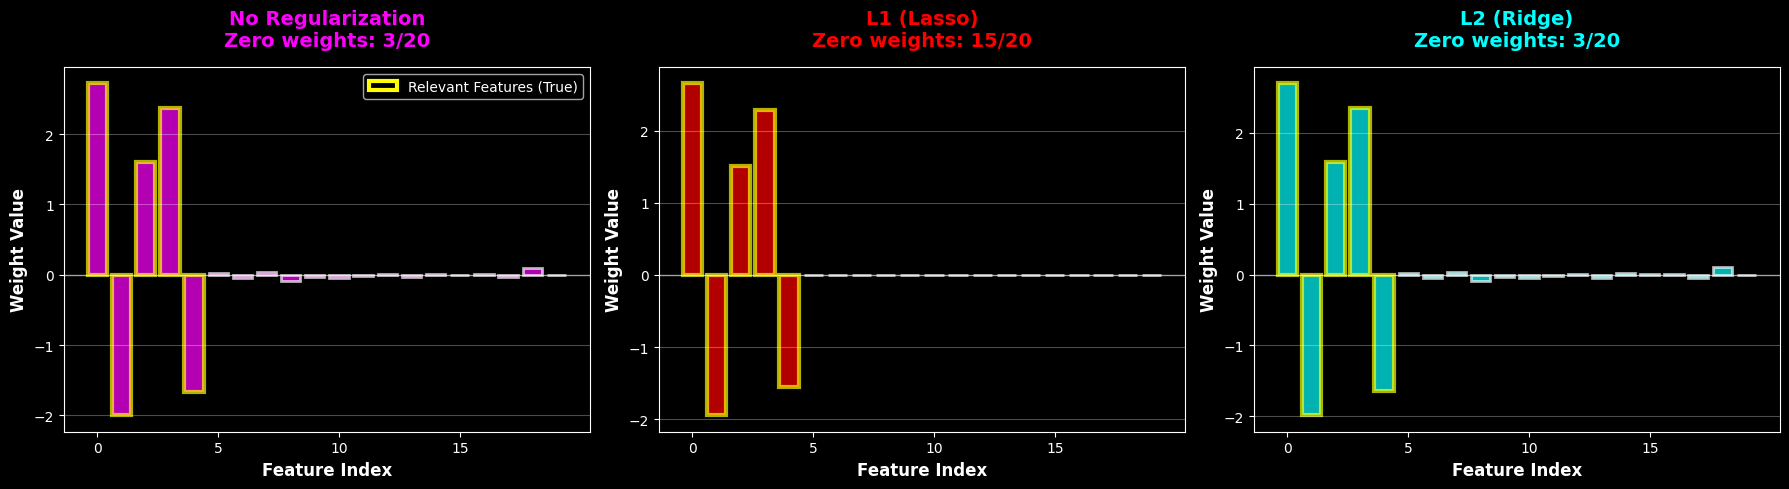


Observations:
NO REGULARIZATION: All weights non-zero (overfits!)
L1 (LASSO): Many weights = 0 (SPARSE, feature selection!)
L2 (RIDGE): All weights shrunk but non-zero


In [5]:
# Visualize weights
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_models = ['magenta', 'red', 'cyan']

for ax, (name, w), color in zip(axes, weights.items(), colors_models):
    # Bar plot
    x_pos = np.arange(n_features)
    bars = ax.bar(x_pos, w, color=color, alpha=0.7, edgecolor='white', linewidth=2)
    
    # Highlight relevant features
    for i in range(n_relevant):
        bars[i].set_edgecolor('yellow')
        bars[i].set_linewidth(3)
    
    # Add zero line
    ax.axhline(y=0, color='white', linewidth=1, alpha=0.5)
    
    # Count zeros for L1
    n_zeros = np.sum(np.abs(w) < 0.01)
    
    ax.set_xlabel('Feature Index', fontsize=12, fontweight='bold')
    ax.set_ylabel('Weight Value', fontsize=12, fontweight='bold')
    ax.set_title(f'{name}\nZero weights: {n_zeros}/{n_features}', 
                fontsize=14, fontweight='bold', color=color, pad=15)
    ax.grid(alpha=0.3, axis='y')
    ax.set_xticks(range(0, n_features, 5))

# Add legend to first plot
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='none', edgecolor='yellow', linewidth=3, 
                         label='Relevant Features (True)')]
axes[0].legend(handles=legend_elements, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

print("\nObservations:")
print("="*60)
print("NO REGULARIZATION: All weights non-zero (overfits!)")
print("L1 (LASSO): Many weights = 0 (SPARSE, feature selection!)")
print("L2 (RIDGE): All weights shrunk but non-zero")
print("="*60)

## 5. Regularization Strength Effect

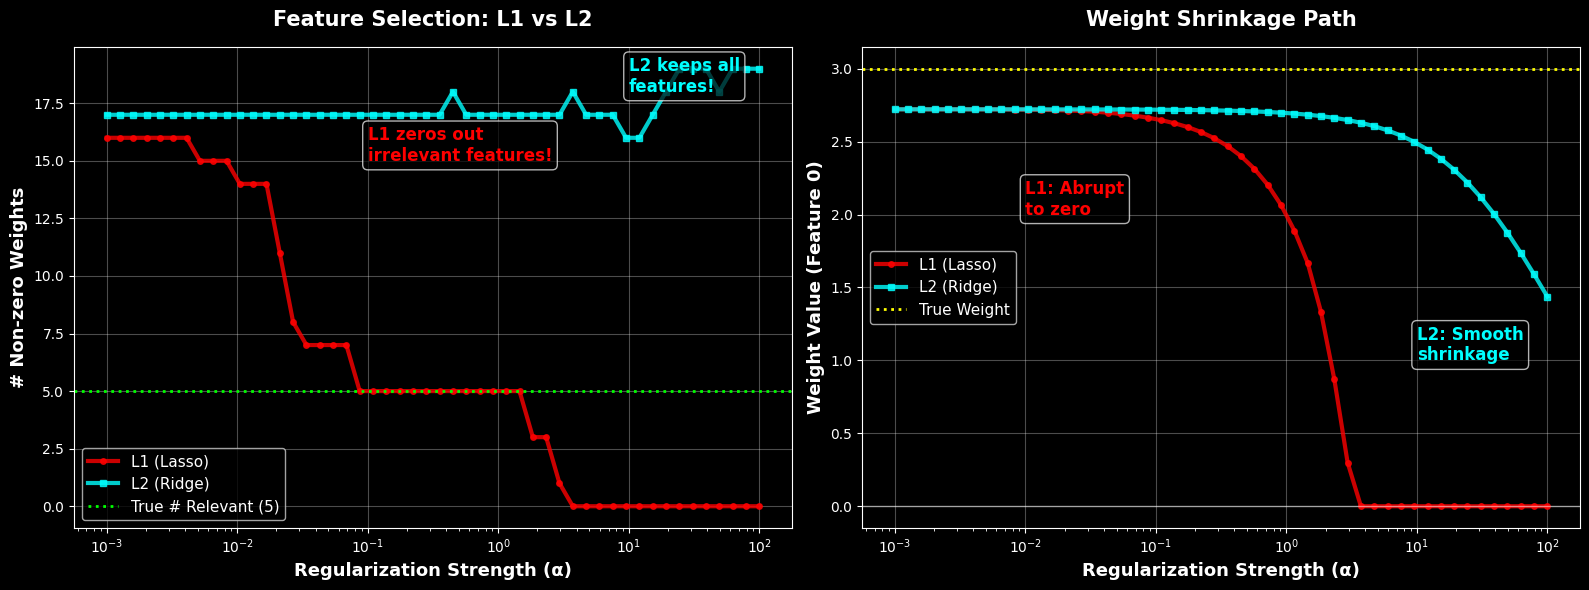


Key Insight:
L1 creates SPARSE models (automatic feature selection!)
L2 shrinks ALL weights smoothly (no feature selection)


In [6]:
# Test different regularization strengths
alphas = np.logspace(-3, 2, 50)
n_nonzero_l1 = []
n_nonzero_l2 = []
weights_l1_0 = []
weights_l2_0 = []

for alpha in alphas:
    # L1
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_scaled, y)
    n_nonzero_l1.append(np.sum(np.abs(lasso.coef_) > 0.01))
    weights_l1_0.append(lasso.coef_[0])
    
    # L2
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_scaled, y)
    n_nonzero_l2.append(np.sum(np.abs(ridge.coef_) > 0.01))
    weights_l2_0.append(ridge.coef_[0])

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Number of non-zero weights
ax1 = axes[0]
ax1.plot(alphas, n_nonzero_l1, 'red', linewidth=3, marker='o', 
        markersize=4, label='L1 (Lasso)', alpha=0.8)
ax1.plot(alphas, n_nonzero_l2, 'cyan', linewidth=3, marker='s', 
        markersize=4, label='L2 (Ridge)', alpha=0.8)
ax1.axhline(y=n_relevant, color='lime', linestyle=':', linewidth=2, 
           label=f'True # Relevant ({n_relevant})')
ax1.set_xscale('log')
ax1.set_xlabel('Regularization Strength (α)', fontsize=13, fontweight='bold')
ax1.set_ylabel('# Non-zero Weights', fontsize=13, fontweight='bold')
ax1.set_title('Feature Selection: L1 vs L2', fontsize=15, fontweight='bold', pad=15)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Annotation
ax1.text(0.1, 15, 'L1 zeros out\nirrelevant features!', 
        fontsize=12, color='red', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
ax1.text(10, 18, 'L2 keeps all\nfeatures!', 
        fontsize=12, color='cyan', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# Plot 2: Weight shrinkage
ax2 = axes[1]
ax2.plot(alphas, weights_l1_0, 'red', linewidth=3, marker='o', 
        markersize=4, label='L1 (Lasso)', alpha=0.8)
ax2.plot(alphas, weights_l2_0, 'cyan', linewidth=3, marker='s', 
        markersize=4, label='L2 (Ridge)', alpha=0.8)
ax2.axhline(y=0, color='white', linewidth=1, alpha=0.5)
ax2.axhline(y=true_weights[0], color='yellow', linestyle=':', linewidth=2, 
           label='True Weight')
ax2.set_xscale('log')
ax2.set_xlabel('Regularization Strength (α)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Weight Value (Feature 0)', fontsize=13, fontweight='bold')
ax2.set_title('Weight Shrinkage Path', fontsize=15, fontweight='bold', pad=15)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

# Annotation
ax2.text(0.01, 2, 'L1: Abrupt\nto zero', 
        fontsize=12, color='red', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
ax2.text(10, 1, 'L2: Smooth\nshrinkage', 
        fontsize=12, color='cyan', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

print("\nKey Insight:")
print("L1 creates SPARSE models (automatic feature selection!)")
print("L2 shrinks ALL weights smoothly (no feature selection)")

## 6. Key Takeaways

### Regularization:
**Penalty added to loss function to prevent overfitting**

### L1 Regularization (Lasso):
**Loss = MSE + α × Σ|wᵢ|**

**Characteristics:**
- Penalty: Sum of absolute values
- Shape: Diamond (in 2D)
- Effect: SPARSE solutions (many weights = 0)
- Use case: Feature selection

**Advantages:**
- ✓ Automatic feature selection
- ✓ Interpretable (fewer features)
- ✓ Works well with many irrelevant features

**Disadvantages:**
- ✗ If features correlated, picks one arbitrarily
- ✗ Can be unstable

### L2 Regularization (Ridge):
**Loss = MSE + α × Σwᵢ²**

**Characteristics:**
- Penalty: Sum of squared values
- Shape: Circle (in 2D)
- Effect: Smooth weight shrinkage
- Use case: When all features potentially relevant

**Advantages:**
- ✓ Stable, always has solution
- ✓ Handles correlated features well
- ✓ Computationally efficient

**Disadvantages:**
- ✗ No feature selection
- ✗ All features retained (less interpretable)

### When to Use:

**Use L1 when:**
- You have many features
- You suspect many are irrelevant
- You want feature selection
- Interpretability is important

**Use L2 when:**
- All features might be relevant
- Features are correlated
- You want stability
- Computational efficiency matters

**Use Both (Elastic Net):**
- Loss = MSE + α₁ × Σ|wᵢ| + α₂ × Σwᵢ²
- Best of both worlds!
- Combines sparsity + stability

### Hyperparameter α:
- **α = 0**: No regularization (overfitting risk)
- **α small**: Light penalty
- **α large**: Heavy penalty (underfitting risk)
- **Tune with cross-validation!**

### Remember:
**L1 = Feature selection (sparse)**

**L2 = Weight shrinkage (smooth)**

Both prevent overfitting! 🎯